In [1]:
import matplotlib.pyplot as plt

from rgfn import ReactionDataFactory
from rgfn.gfns.reaction_gfn.proxies.path_cost_proxy import PathCostProxy
from notebooks.utils.sampling_results import SamplingResult
from collections import defaultdict
from pathlib import Path

import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

from notebooks.utils.training_results import TrainingResults

template_name = 'synflow_64'
task_name = 'seh'
data_dir = Path('../../data')
threshold = 8.0 if task_name == 'seh' else 0.0


def get_path_cost_proxy(templates_name: str, sanitized: bool) -> PathCostProxy:
    if 'synflow' in templates_name:
        k = int(templates_name.split('_')[-1])
        return PathCostProxy(
            data_factory=ReactionDataFactory(
                reaction_path=data_dir / f'synflow/templates.txt',
                fragment_path=data_dir / f'synflow/fragment_{k}k.txt',
                cost_path=data_dir / f'synflow/fragment_{k}k_to_real_cost_sanitized.json' if sanitized else data_dir / f'synflow/fragment_{k}k_to_real_cost.json',
            ),
            yield_value=0.75
        )
    elif templates_name == 'rgfn_new_filtered':
        return PathCostProxy(data_factory=ReactionDataFactory(
            reaction_path=data_dir / f'rgfn_new_filtered/templates.txt',
            fragment_path=data_dir / f'rgfn_new_filtered/fragments.txt',
            cost_path=data_dir / f'rgfn_new_filtered/fragment_to_real_cost_sanitized.json' if sanitized else data_dir / f'rgfn_new_filtered/fragment_to_real_cost.json',
            yield_path=data_dir / f'rgfn_new_filtered/templates_yields.csv',
        ))
    else:
        raise ValueError(f"Unknown templates_name: {templates_name}")

path_cost_proxy = get_path_cost_proxy(template_name, sanitized=False)
sanitized_path_cost_proxy = get_path_cost_proxy(template_name, sanitized=True)

Using 64000 fragments, 105 reactions, and 197 anchored reactions
Cost mean and variance (165.35871676652314, 141.97387057883336)
Cost max 999.2437529950079
Using 64000 fragments, 105 reactions, and 197 anchored reactions
Cost mean and variance (165.4397748146447, 141.61053237141817)
Cost max 999.2437529950079


In [2]:
import numpy as np
from rdkit.Chem import MolFromSmiles, AllChem
from rdkit import DataStructs, Chem


def _get_fp(smiles: str, fp_type: str):
    if 'morgan' in fp_type:
        radius = int(fp_type[-1])
        return AllChem.GetMorganFingerprintAsBitVect(
            MolFromSmiles(smiles), radius=radius, nBits=2048, useFeatures=False, useChirality=False
        )
    else:
        return Chem.RDKFingerprint(MolFromSmiles(smiles))

def get_costs(result: SamplingResult, indices):
    actual_path_cost_proxy = sanitized_path_cost_proxy if 'synflow' in result.model_name else path_cost_proxy

    costs = []
    paths = [result.paths[i] for i in indices]
    for path in tqdm(paths, desc='path_costs'):
        current_molecule = path[0]
        current_cost = actual_path_cost_proxy.get_fragment_cost(current_molecule)
        reaction = None
        input_molecules = None
        fragment_costs = None
        counter = 0
        for molecule_or_reaction in path[1:]:
            if isinstance(molecule_or_reaction, str):
                yield_value = actual_path_cost_proxy.compute_yield_raw(input_smiles_list=input_molecules,
                                                                       output_smiles=molecule_or_reaction,
                                                                       reaction=reaction)
                current_cost = fragment_costs * yield_value ** -1
                current_molecule = molecule_or_reaction
                counter += 1
            else:
                reaction = molecule_or_reaction[0]
                fragments_smiles = [m for m in molecule_or_reaction[1:] if isinstance(m, str)]
                input_molecules = [current_molecule] + fragments_smiles
                fragment_costs = current_cost + sum(
                    actual_path_cost_proxy.get_fragment_cost(m) for m in fragments_smiles)
        costs.append(current_cost)

    return costs

def get_tanimoto_similarity(result: SamplingResult, indices):
    all_ecfp_list = [_get_fp(mol, 'morgan_3') for mol in result.molecules]
    all_ecfp_list = [all_ecfp_list[i] for i in indices]
    tanimoto_similarities = []
    for i in tqdm(range(len(all_ecfp_list)), desc='tanimoto_similarities'):
        similarities = DataStructs.BulkTanimotoSimilarity(all_ecfp_list[i], all_ecfp_list[:i] + all_ecfp_list[i + 1:])
        tanimoto_similarities.extend(similarities)
    return tanimoto_similarities

name_map = {
    'rgfn_cost_reward_proper': 'cost reward',
    'rgfn_48k_cheapest': 'w/ 25% top expensive',
    'rgfn_56k_cheapest': 'w/ 12.5% top expensive',
    'rgfn_cost_biasing': 'cost guidance',
    'rgfn_is_decomposable': 'w/o cost guidance',
}
if template_name == 'synflow_64':
    model_names = ['rgfn_is_decomposable', 'rgfn_48k_cheapest', 'rgfn_56k_cheapest', 'rgfn_cost_reward_proper', 'rgfn_cost_biasing']
else:
    model_names = ['rgfn_cost_reward_proper', 'rgfn_rl_cost', 'rgfn_380_cheapest', 'rgfn_400_cheapest', 'rgfn_cost_biasing']

dfs = []
dfs_sim = []
dfs_cost = []
for seed in range(10):
    for model_name in tqdm(model_names):
        try:
            result = SamplingResult(
                model_name=model_name,
                templates_name=template_name,
                seed=seed,
                task_name=task_name,
                threshold=threshold,
                results_dir=Path('../results'),
            )
        except FileNotFoundError:
            print(f'File not found: {model_name}, {seed}')
            continue
        high_reward_indices = np.array([i for i, r in enumerate(result.rewards) if r > threshold], dtype=int)
        df = pd.DataFrame(
            {
                'rewards': result.rewards,
            }
        )
        df_cost = pd.DataFrame(
            {
                'costs': get_costs(result, high_reward_indices),
            }
        )
        df_sim = pd.DataFrame(
            {
                'similarities': get_tanimoto_similarity(result, high_reward_indices),
            }
        )
        df['model_name'] = name_map[model_name]
        df_sim['model_name'] = name_map[model_name]
        df_cost['model_name'] = name_map[model_name]
        dfs.append(df)
        dfs_sim.append(df_sim)
        dfs_cost.append(df_cost)
        print(model_name, df_cost['costs'].mean())
df = pd.concat(dfs)
df_sim = pd.concat(dfs_sim)
df_cost = pd.concat(dfs_cost)

  0%|          | 0/5 [00:00<?, ?it/s]

path_costs:   0%|          | 0/65 [00:00<?, ?it/s]

tanimoto_similarities:   0%|          | 0/65 [00:00<?, ?it/s]

rgfn_is_decomposable 1473.7076974893512


path_costs:   0%|          | 0/65 [00:00<?, ?it/s]

...

File not found: rgfn_is_decomposable, 7
File not found: rgfn_48k_cheapest, 7
File not found: rgfn_56k_cheapest, 7
File not found: rgfn_cost_reward_proper, 7
File not found: rgfn_cost_biasing, 7


  0%|          | 0/5 [00:00<?, ?it/s]

File not found: rgfn_is_decomposable, 8
File not found: rgfn_48k_cheapest, 8
File not found: rgfn_56k_cheapest, 8
File not found: rgfn_cost_reward_proper, 8
File not found: rgfn_cost_biasing, 8


  0%|          | 0/5 [00:00<?, ?it/s]

File not found: rgfn_is_decomposable, 9
File not found: rgfn_48k_cheapest, 9
File not found: rgfn_56k_cheapest, 9
File not found: rgfn_cost_reward_proper, 9
File not found: rgfn_cost_biasing, 9


In [3]:
from notebooks.utils.training_results import TrainingResultsList

results_dict = {}

for model_name in tqdm(model_names):
    results_list = []
    for seed in range(3):
        try:
            result = TrainingResults(
                model_name=model_name,
                templates_name=template_name,
                seed=seed,
                task_name='seh',
                threshold=threshold,
                results_dir=Path('../results'),
            )
            results_list.append(result)
        except FileNotFoundError:
            print(f'File not found: {model_name}, {seed}')
    results_dict[model_name] = TrainingResultsList(results_list)

  0%|          | 0/5 [00:00<?, ?it/s]

/var/folders/5d/02_f0b1n3s9dx9kzhkqmt2cw0000gn/T/ipykernel_11310/3611724471.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df_cost["model_name"],  y=df_cost['costs'], inner='box', palette='muted', legend=None)


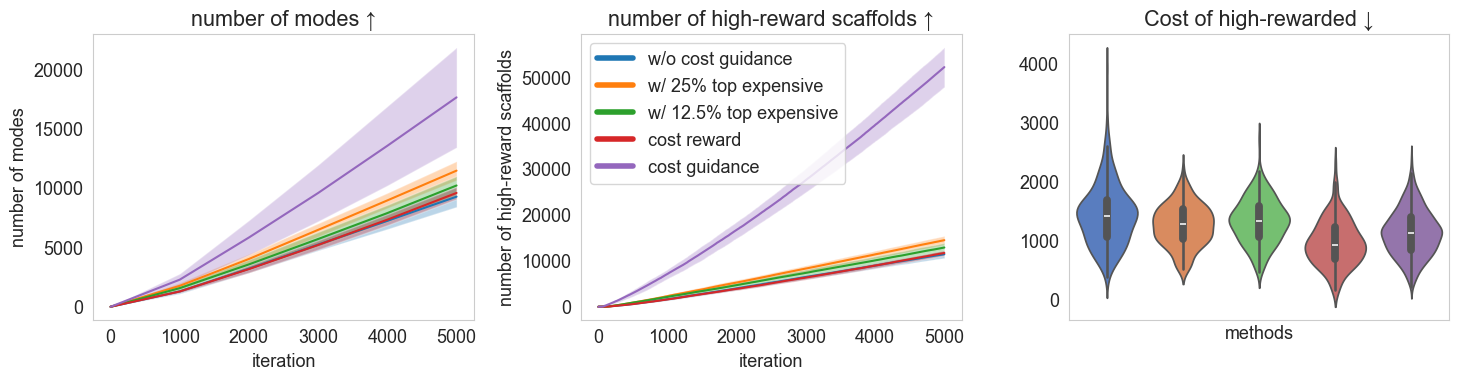

In [6]:
from typing import Literal
import matplotlib.pyplot as plt
modes_every_n_iteration = 1000
n_forward_in_batch = 64

def plot_metric(results: TrainingResultsList, metric: str, max_or_std: Literal['max', 'std'] = 'std'):
    plt.grid(False)
    results = results.results
    max_len_results_idx = np.argmax([len(result.__getattribute__(metric)) for result in results])
    if 'modes' in metric:
        x = [i * modes_every_n_iteration for i in range(0, len(results[max_len_results_idx].num_modes) + 1)]
        y = [[0] + list(result.num_modes) for result in results]
    else:
        x = range(len(results[max_len_results_idx].num_scaffolds[::n_forward_in_batch]))
        y = [result.__getattribute__(metric)[::n_forward_in_batch] for result in results]

    if metric == 'cheapest_scaffolds_path_costs':
        x = x[1000:]
        y = [y_i[1000:] for y_i in y]

    max_len = max(len(y_i) for y_i in y)
    y = [np.pad(y_i, (0, max_len - len(y_i)), mode='edge') for y_i in y]
    y_mean = np.mean(y, axis=0)
    name = name_map.get(results[0].model_name, results[0].model_name)

    if 'disabled' in name:
        style = ':'
    elif 'uniform' in name:
        style = '--'
    elif 'count-based' in name:
        style = '-'
    # style = '-' if 'disabled' in name else '--'
    plt.plot(x, y_mean, label=name)

    if max_or_std == 'std':
        y_std = np.std(y, axis=0)
        _floor = y_mean - y_std
        _floor[_floor < 0] = 0
        plt.fill_between(x, _floor, y_mean + y_std, alpha=0.3)
    elif max_or_std == 'max':
        y_min = np.min(y, axis=0)
        y_max = np.max(y, axis=0)
        plt.fill_between(x, y_min, y_max, alpha=0.3)
        
import matplotlib
matplotlib.rcParams.update({'font.size': 13})
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.xlabel('iteration')
plt.ylabel('number of modes')
plt.title(u'number of modes \u2191')
for model_name, results_list in results_dict.items():
    plot_metric(results_list, 'num_modes', 'std')


plt.subplot(1, 3, 2)
plt.xlabel('iteration')
plt.ylabel('number of high-reward scaffolds')
plt.title(u'number of high-reward scaffolds \u2191')
plt.grid(False)
for model_name, results_list in results_dict.items():
    plot_metric(results_list, 'num_scaffolds', 'std')
    leg = plt.legend()
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    # plt.legend()
# sns.violinplot(x=df["model_name"], y=df["rewards"], inner='box', palette='muted')
# plt.xlabel('')
# plt.ylabel('')
# if task_name == 'seh':
#     plt.title(u'sEH proxy \u2191')
# elif task_name == 'gsk':
#     plt.title(u'GSK3\u03B2 proxy \u2191')
# else:
#     plt.title(u'JNK3 proxy \u2191')

plt.subplot(1, 3, 3)
sns.violinplot(x=df_cost["model_name"],  y=df_cost['costs'], inner='box', palette='muted', legend=None)
# plt.ylim(-20, 100)
plt.xlabel('')
plt.ylabel('')
if threshold > 0:   
    plt.title(u'Cost of high-rewarded \u2193')
else:
    plt.title(u'Cost \u2193')
plt.tight_layout()
plt.grid(False)
# remove xticks
plt.xticks([])
plt.xlabel('methods')


plt.savefig(f'outputs/cost_ablation_plots_{task_name}_{template_name}.pdf', bbox_inches = 'tight')
# plt.title(u'sEH proxy \u2193')